In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
file_path = 'customer_behavior_5000_noisy.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

  Customer_ID  Age  Gender  Annual_Income  Spending_Score       City  \
0      C00001   39  Female      113338.10           43.34    Kolkata   
1      C00002   33    Male       61943.12           81.32    Kolkata   
2      C00003   41  Female       82333.63           60.36    Chennai   
3      C00004   50  Female       64641.89           60.75  Bangalore   
4      C00005   32  Female       69977.66           35.95      Delhi   

   Transaction_Count  Avg_Purchase_Value Membership_Type  Churn  
0                 27              279.53            Gold      0  
1                 22              393.47          Silver      0  
2                 21              442.56          Silver      0  
3                 13              286.27          Silver      1  
4                 22              502.26          Silver      0  


In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Dataset information
print("\nDataset Info:\n")
df.info()

Dataset Shape: (5000, 10)

Columns:
 Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Spending_Score',
       'City', 'Transaction_Count', 'Avg_Purchase_Value', 'Membership_Type',
       'Churn'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         5000 non-null   object 
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Annual_Income       4752 non-null   float64
 4   Spending_Score      4764 non-null   float64
 5   City                5000 non-null   object 
 6   Transaction_Count   5000 non-null   int64  
 7   Avg_Purchase_Value  5000 non-null   float64
 8   Membership_Type     5000 non-null   object 
 9   Churn               5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ K

In [4]:
# Statistical summary
print(df.describe())

               Age  Annual_Income  Spending_Score  Transaction_Count  \
count  5000.000000    4752.000000     4764.000000        5000.000000   
mean     34.757400   62114.197696       60.298829          20.005200   
std       9.515727   25281.613029       19.634841           4.528496   
min      18.000000   10000.000000        1.000000           7.000000   
25%      28.000000   46983.715000       46.767500          17.000000   
50%      35.000000   60281.135000       60.415000          20.000000   
75%      41.000000   74189.162500       74.020000          23.000000   
max      70.000000  200000.000000      100.000000          37.000000   

       Avg_Purchase_Value        Churn  
count         5000.000000  5000.000000  
mean           299.746526     0.298400  
std             99.805863     0.457602  
min             50.000000     0.000000  
25%            231.137500     0.000000  
50%            298.020000     0.000000  
75%            366.830000     1.000000  
max            729.8900

In [5]:
# Missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Customer_ID             0
Age                     0
Gender                  0
Annual_Income         248
Spending_Score        236
City                    0
Transaction_Count       0
Avg_Purchase_Value      0
Membership_Type         0
Churn                   0
dtype: int64


In [6]:
# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
# Remove duplicates
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print("Rows Before:", before)
print("Rows After:", after)

Rows Before: 5000
Rows After: 5000


In [8]:
# Fill numerical missing values with median
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
City                  0
Transaction_Count     0
Avg_Purchase_Value    0
Membership_Type       0
Churn                 0
dtype: int64


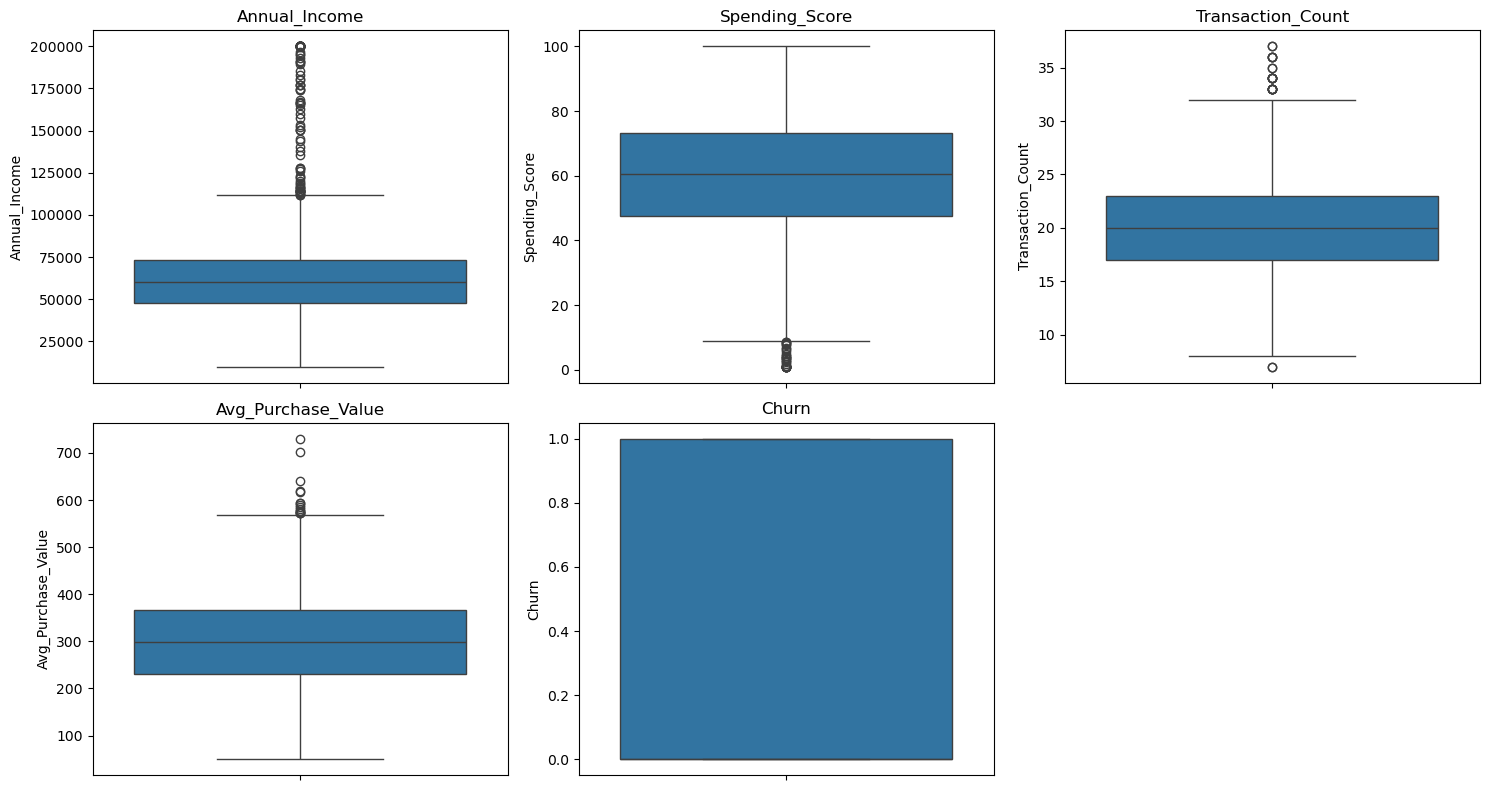

In [9]:
# Boxplots for numerical columns
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols[1:], 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [10]:
# Function to remove outliers
for col in numerical_cols[1:]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape After Removing Outliers:", df.shape)

Shape After Removing Outliers: (4832, 10)


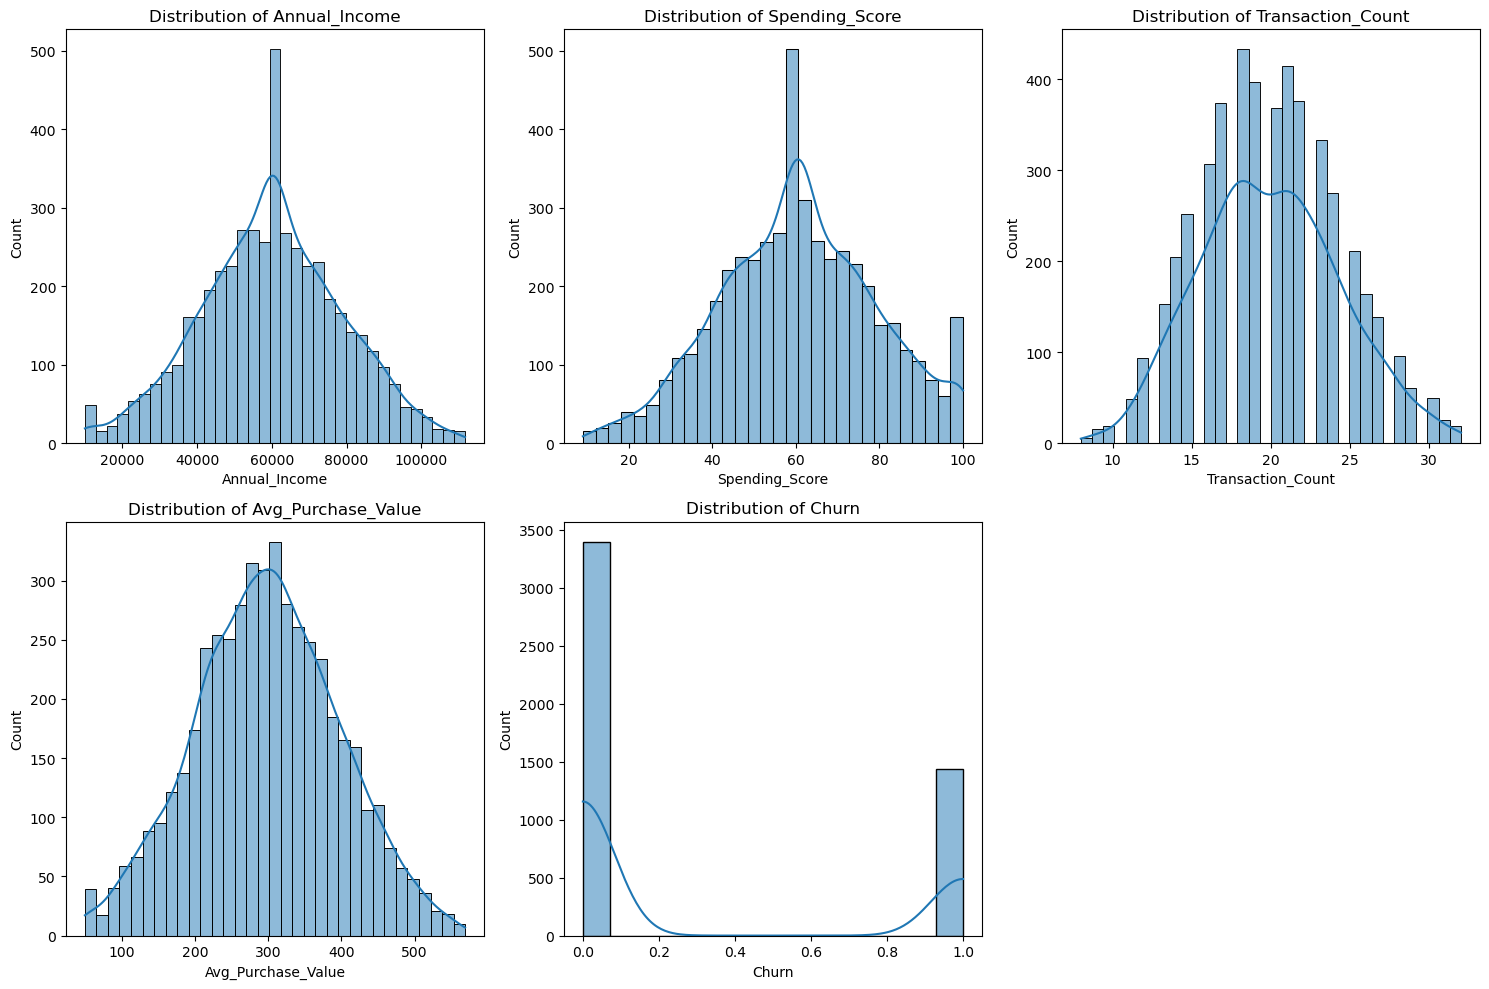

In [11]:
# Histograms
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols[1:], 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

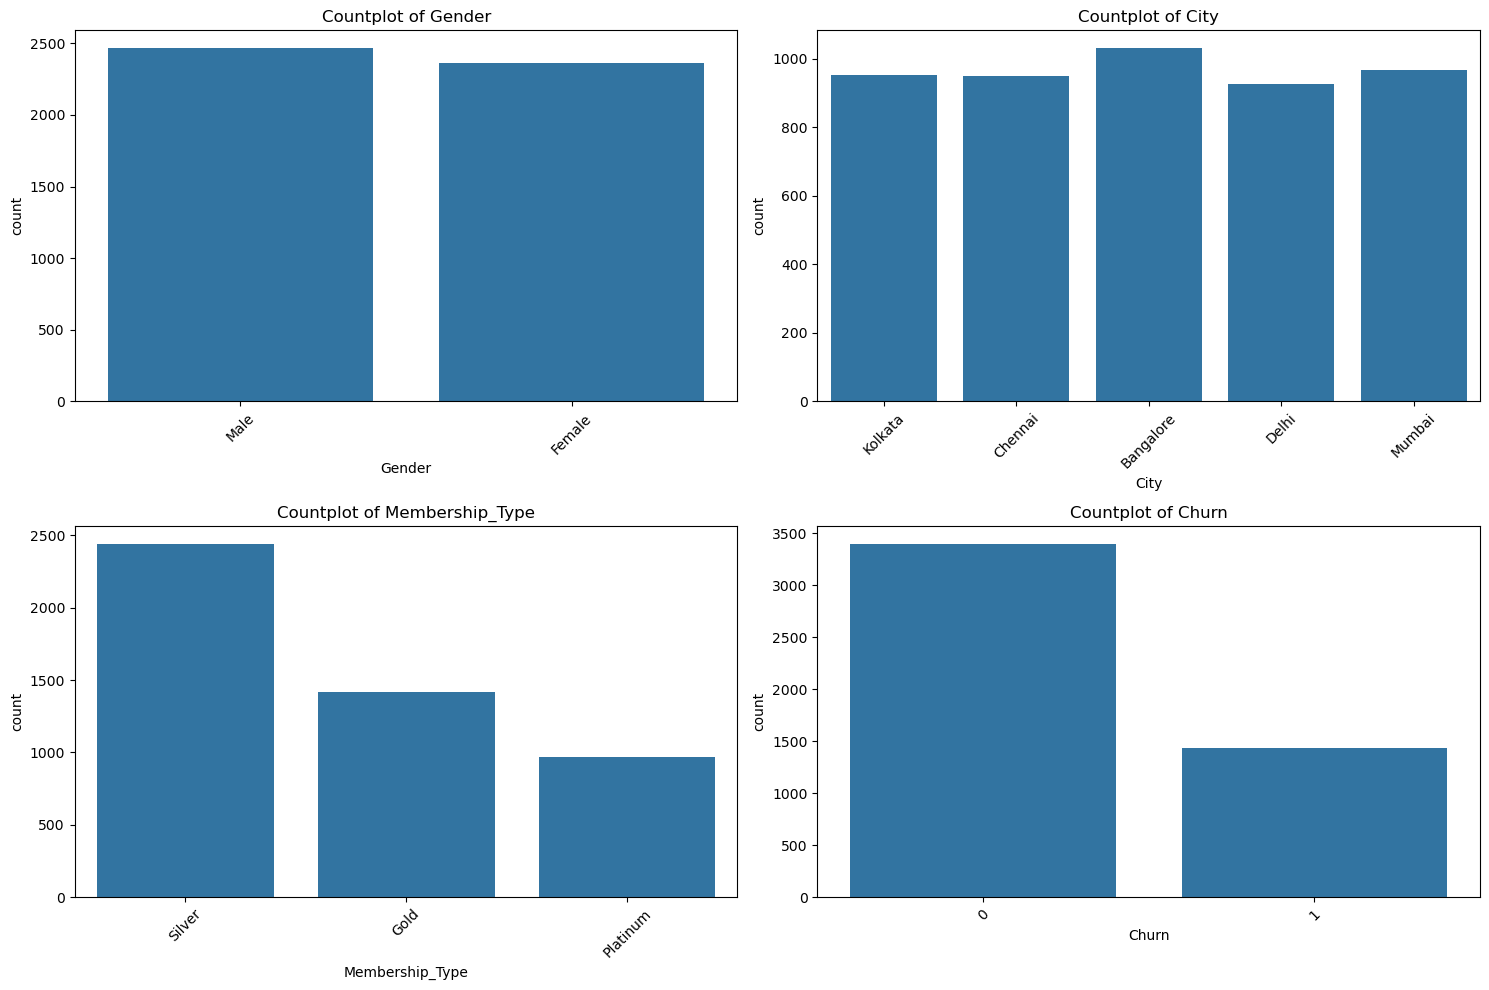

In [12]:
categorical_cols = ['Gender', 'City', 'Membership_Type', 'Churn']

plt.figure(figsize=(15,10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

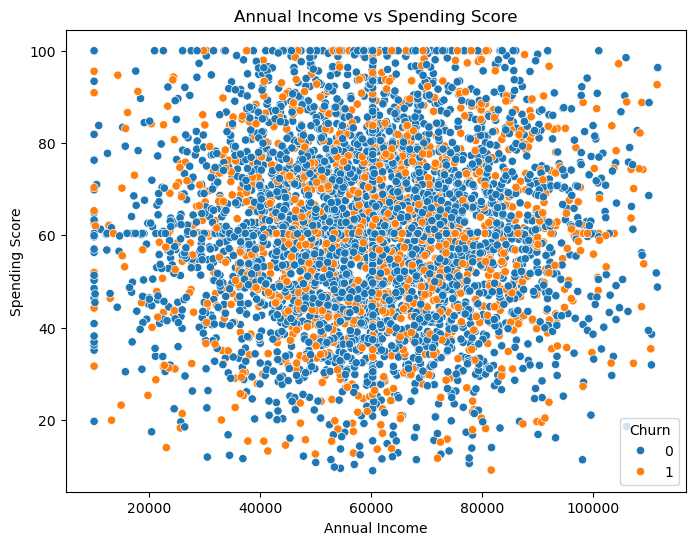

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Churn', data=df)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

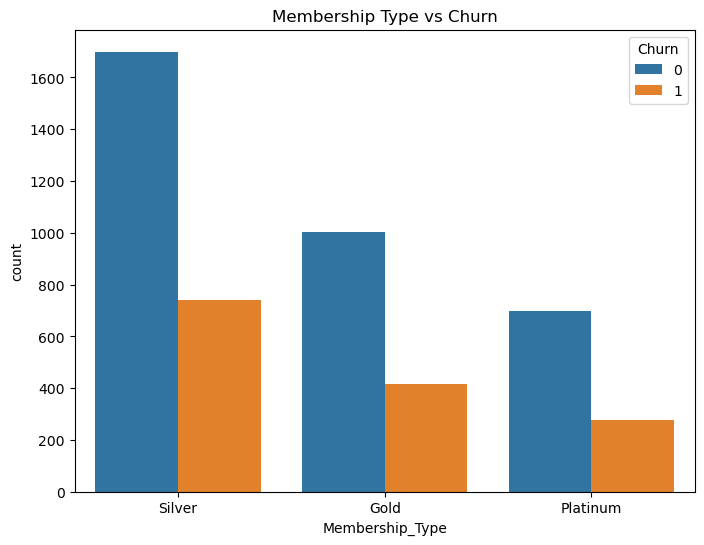

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(x='Membership_Type', hue='Churn', data=df)
plt.title('Membership Type vs Churn')
plt.show()

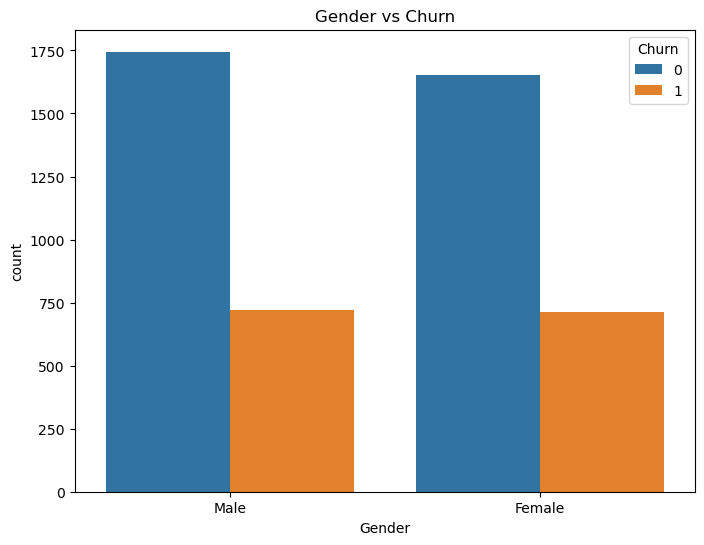

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(x='Gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()

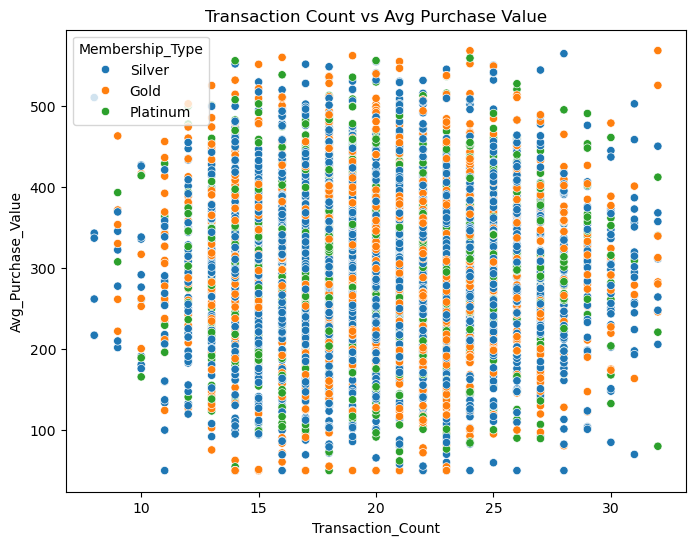

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Transaction_Count', y='Avg_Purchase_Value', hue='Membership_Type', data=df)
plt.title('Transaction Count vs Avg Purchase Value')
plt.show()

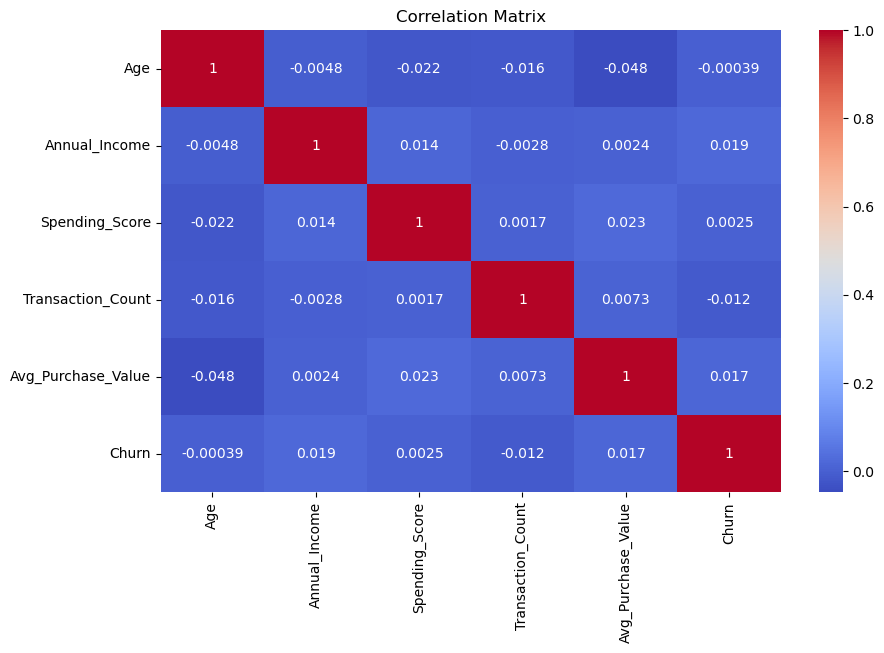

In [17]:
# Correlation matrix
plt.figure(figsize=(10,6))

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

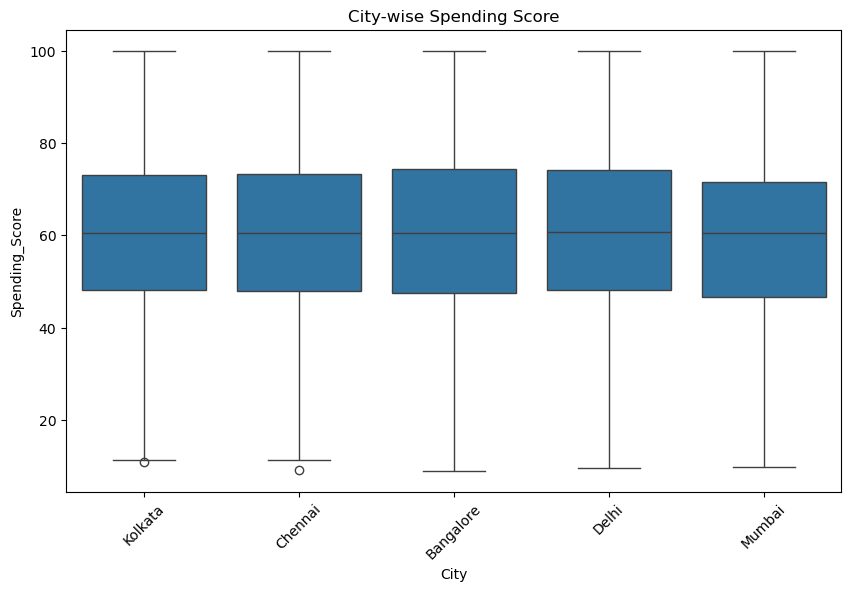

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='City', y='Spending_Score', data=df)
plt.title('City-wise Spending Score')
plt.xticks(rotation=45)
plt.show()

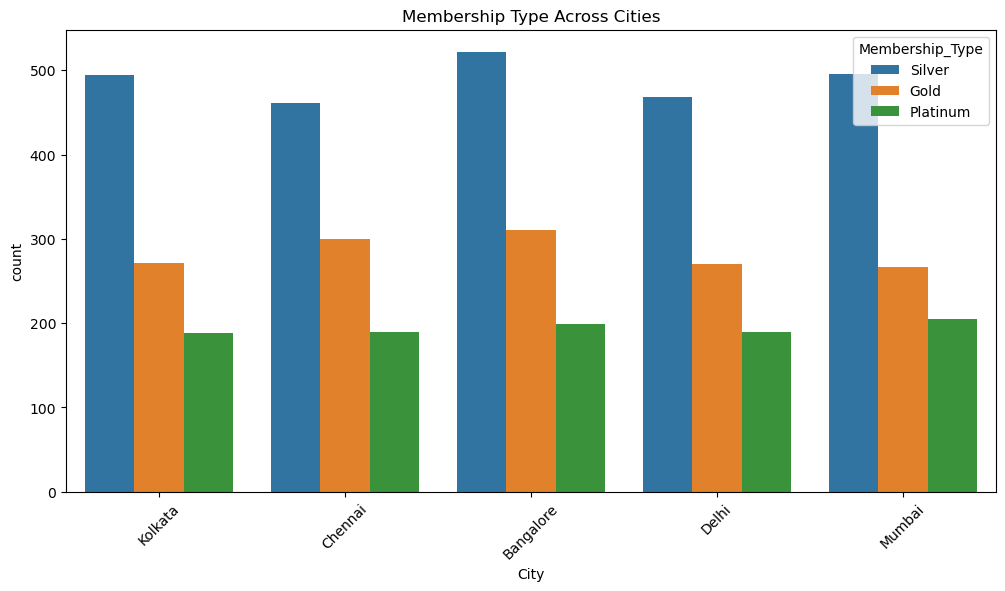

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(x='City', hue='Membership_Type', data=df)
plt.title('Membership Type Across Cities')
plt.xticks(rotation=45)
plt.show()

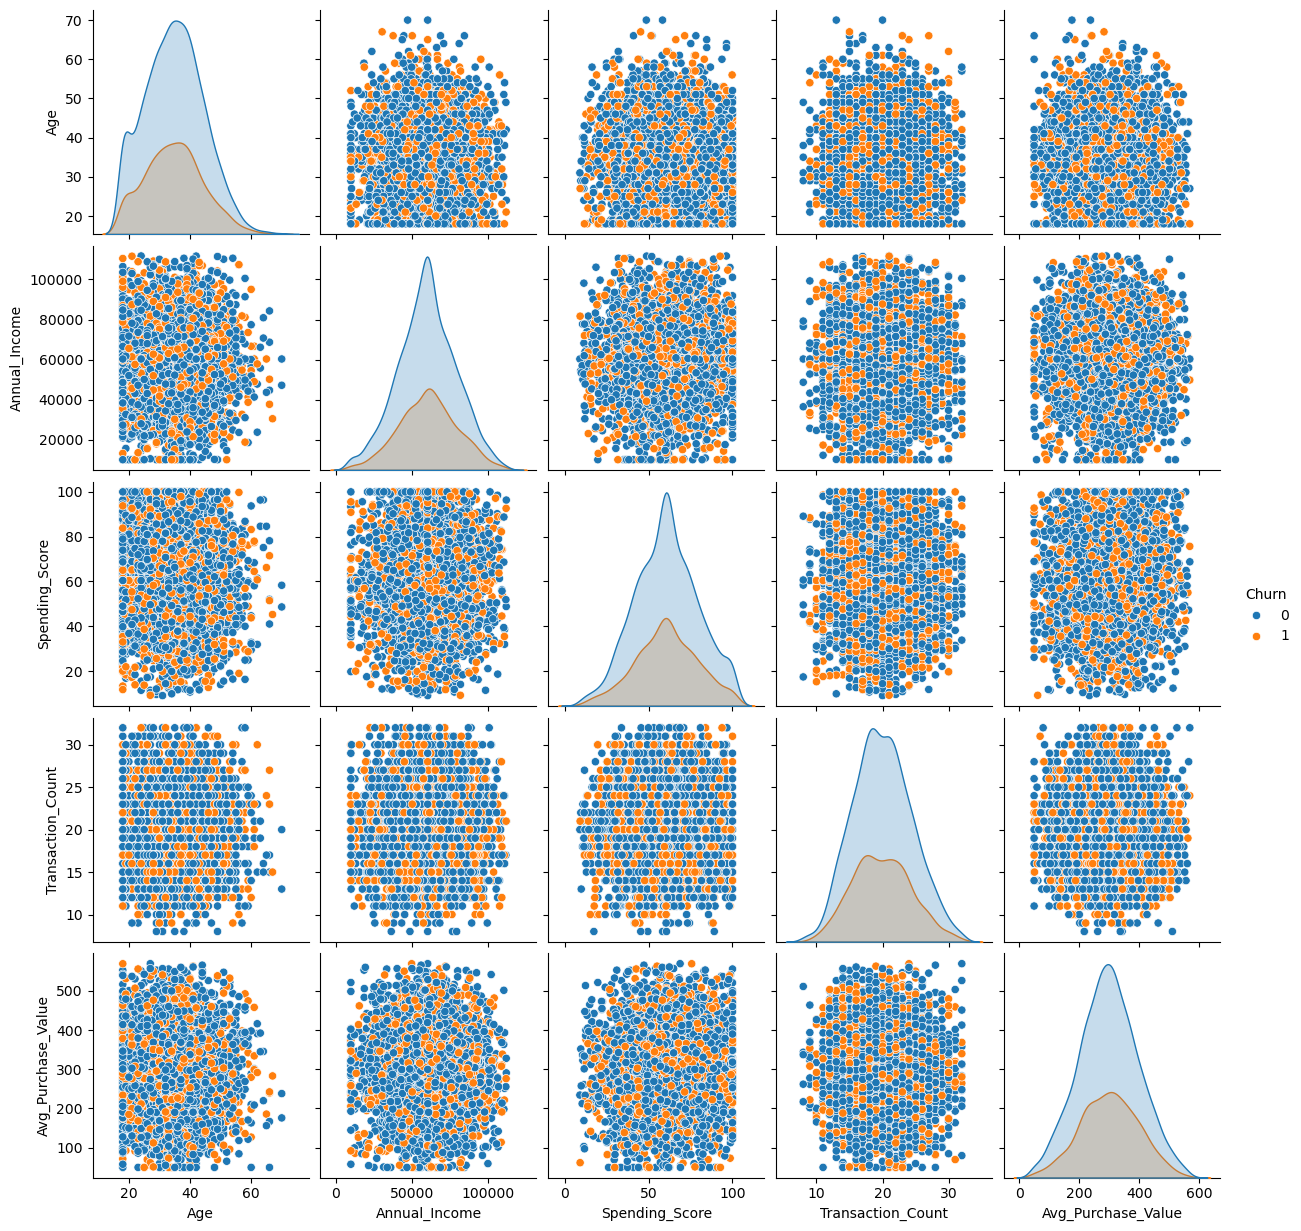

In [20]:
sns.pairplot(df[['Age', 'Annual_Income', 'Spending_Score',
                 'Transaction_Count', 'Avg_Purchase_Value', 'Churn']],
             hue='Churn')
plt.show()

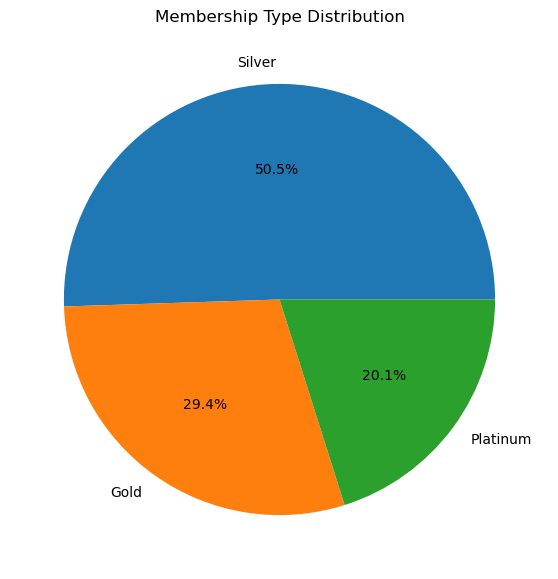

In [21]:
membership_counts = df['Membership_Type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(membership_counts,
        labels=membership_counts.index,
        autopct='%1.1f%%')

plt.title('Membership Type Distribution')
plt.show()

In [22]:
# Create new feature: Total Spend
df['Total_Spend'] = df['Transaction_Count'] * df['Avg_Purchase_Value']

# Create customer category
def customer_category(x):
    if x > 10000:
        return 'High Value'
    elif x > 5000:
        return 'Medium Value'
    else:
        return 'Low Value'

df['Customer_Category'] = df['Total_Spend'].apply(customer_category)

# Display new columns
print(df[['Transaction_Count', 'Avg_Purchase_Value', 'Total_Spend', 'Customer_Category']].head())

   Transaction_Count  Avg_Purchase_Value  Total_Spend Customer_Category
1                 22              393.47      8656.34      Medium Value
2                 21              442.56      9293.76      Medium Value
3                 13              286.27      3721.51         Low Value
4                 22              502.26     11049.72        High Value
5                 22              126.14      2775.08         Low Value


In [23]:
# Identify high-value customers
high_value_customers = df[df['Customer_Category'] == 'High Value']

print(high_value_customers.head())
print("Total High Value Customers:", high_value_customers.shape[0])

   Customer_ID  Age  Gender  Annual_Income  Spending_Score       City  \
4       C00005   32  Female       69977.66           35.95      Delhi   
25      C00026   36  Female       46565.58           53.98      Delhi   
29      C00030   32    Male      101821.89           77.79  Bangalore   
57      C00058   31  Female       68096.47           49.57     Mumbai   
61      C00062   33    Male       61103.98           64.25      Delhi   

    Transaction_Count  Avg_Purchase_Value Membership_Type  Churn  Total_Spend  \
4                  22              502.26          Silver      0     11049.72   
25                 27              420.51          Silver      0     11353.77   
29                 20              541.03          Silver      0     10820.60   
57                 23              447.19            Gold      0     10285.37   
61                 25              458.98            Gold      0     11474.50   

   Customer_Category  
4         High Value  
25        High Value  
29   

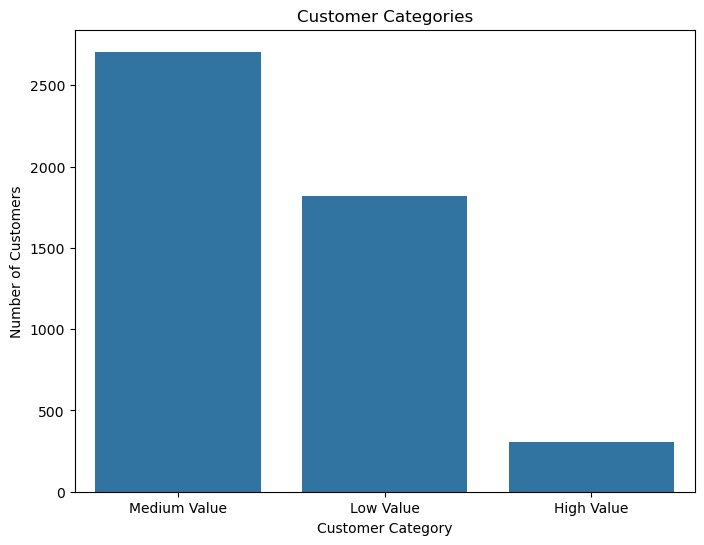

In [24]:
# Visualization of customer categories
plt.figure(figsize=(8,6))
sns.countplot(x='Customer_Category', data=df)

plt.title('Customer Categories')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')

plt.show()